In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

In [3]:
tf.random.set_seed(42)

In [4]:
np.random.seed(42)

In [5]:
VOCAB_SIZE = 10000

In [6]:
(X_train_raw, y_train), (X_test_raw, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

In [7]:
print(f"Training samples: {len(X_train_raw)}, Testing samples: {len(X_test_raw)}")

Training samples: 25000, Testing samples: 25000


In [11]:
print(f"Example label values: {np.unique(y_train)} (0=negative, 1=positive)")

Example label values: [0 1] (0=negative, 1=positive)


In [9]:
np.unique(y_train)

array([0, 1], dtype=int64)

In [10]:
review_lengths = [len(x) for x in X_train_raw]

In [12]:
print(f"   Showing review: {min(review_lengths)} words")

   Showing review: 11 words


In [13]:
print(f"   Showing review: {max(review_lengths)} words")

   Showing review: 2494 words


In [14]:
print(f"   Showing review: {np.mean(review_lengths):.2f} words")

   Showing review: 238.71 words


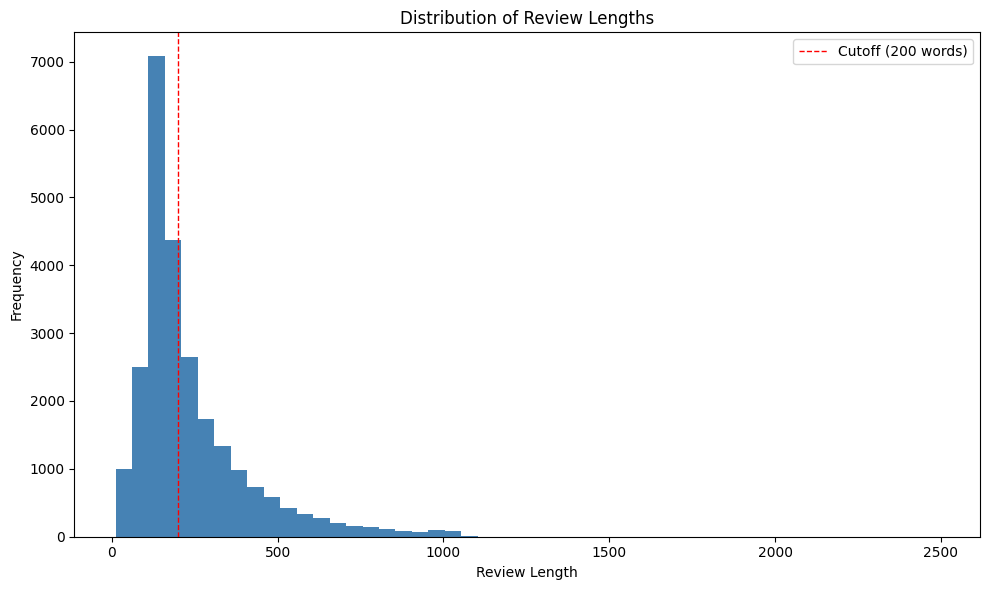

In [19]:
plt.figure(figsize=(10, 6))
plt.hist(review_lengths, bins=50, color='steelblue')
plt.axvline(200, color='red', linestyle='dashed', linewidth=1, label='Cutoff (200 words)')
plt.xlabel("Review Length")
plt.ylabel("Frequency")
plt.title("Distribution of Review Lengths")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
MAX_LEN = 200
X_train = pad_sequences(X_train_raw, maxlen=MAX_LEN, padding='pre', truncating='pre')
X_test = pad_sequences(X_test_raw, maxlen=MAX_LEN, padding='pre', truncating='pre')

In [21]:
print(f"Training samples: {len(X_train_raw)}, Testing samples: {len(X_test_raw)}")

Training samples: 25000, Testing samples: 25000


In [22]:
X_train.shape, X_test.shape

((25000, 200), (25000, 200))

In [23]:
EMBED_DIM = 32
LSTM_UNITS = 64

In [32]:
model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM),
    LSTM(LSTM_UNITS, dropout=0.2, recurrent_dropout=0.2),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

In [33]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [34]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_3 (Embedding)     (None, None, 32)          320000    
                                                                 
 lstm_3 (LSTM)               (None, 64)                24832     
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                                 
Total params: 344897 (1.32 MB)
Trainable params: 344897 (1.32 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [35]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_acc}")



Test Loss: 0.6931157112121582, Test Accuracy: 0.5045199990272522


In [ ]:
EPOCHS = 5
BATCH_SIZE = 128

lstm = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
 16/157 [==>...........................] - ETA: 3:06 - loss: 0.6926 - accuracy: 0.4990